<a href="https://colab.research.google.com/github/lee2998purdue/q15WkH4dkPUakgoM/blob/main/Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Import

In [1]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/gdrive')

data_path = '/content/gdrive/My Drive/Apziva/Project 1 - Happy customers/ACME-HappinessSurvey2020.csv'

Mounted at /content/gdrive


In [2]:

try:
  df = pd.read_csv(data_path)
  print(df.head())
except FileNotFoundError:
  print(f"Error: The file at '{data_path}' was not found. Please check the path.")
except Exception as e:
  print(f"An error occurred while reading the CSV file: {e}")

   Y  X1  X2  X3  X4  X5  X6
0  0   3   3   3   4   2   4
1  0   3   2   3   5   4   3
2  1   5   3   3   3   3   5
3  0   5   4   3   3   3   5
4  0   5   4   3   3   3   5


# Lazy Predict

In [3]:
X = df.iloc[:, 1:]
Y = df['Y']

In [4]:
from sklearn.model_selection import train_test_split
import random

seed = 7133 #random.randint(1000, 9999) #in ML research, 4 digit random seeds are typically used
print(f"Random seed: {seed}")

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=seed)

Random seed: 7133


random seed - make my work reproducible, set the random state to a fixed state

when exploring, it's hard to know if 42 is a good / bad random state

random_state=42 Hitchhiker's Guide to Galaxy: machine's answer to "Purpose of Life" is 42

In [5]:
%pip install lazypredict

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 774.7/774.7 kB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 16.4 MB/s eta 0:00:00


In [6]:
import lazypredict

from lazypredict.Supervised import LazyClassifier

clf = LazyClassifier(predictions=True, random_state=seed)
lazy_models, predictions = clf.fit(X_train, X_test, y_train, y_test)

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 48, number of negative: 40
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000182 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31
[LightGBM] [Info] Number of data points in the train set: 88, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.545455 -> initscore=0.182322
[LightGBM] [Info] Start training from score 0.182322
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [7]:
lazy_models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
BernoulliNB,0.63,0.63,0.63,0.63,0.02
NearestCentroid,0.55,0.56,0.56,0.55,0.02
GaussianNB,0.55,0.56,0.56,0.55,0.02
LogisticRegression,0.55,0.55,0.55,0.55,0.02
RidgeClassifierCV,0.55,0.55,0.55,0.55,0.01
XGBClassifier,0.55,0.54,0.54,0.55,0.10
CalibratedClassifierCV,0.55,0.54,0.54,0.55,0.05
SVC,0.55,0.54,0.54,0.55,0.02
KNeighborsClassifier,0.53,0.52,0.52,0.53,0.02


true positive: predict pos, actual pos

false positivie: predict pos, actual neg

true negative: predict neg, actual neg

false negative: predict neg, actual pos

Accuracy: accuracy classification score

Balanced Accuracy: balanced accuracy (imbalance in the dataset?)

ROC: area under the receiver operating characteristic curve (true positive rate vs false positive rate)

F1 score: harmonic mean of the precision and recall

precision: true positive / (true positive + false postive)

recall = true positive / (true positive + false negative)

The models' accuracy scores change drastically depending on how i split up the train and test dataset. Changes in the test_size and random_state values lead to significant changes in model performances.

This challenge could be coming from having limited data.

Tree models generally perform quite well for tablar data.

Decision Tree Models: yes / no question for each node

Random Forest Model: ensemble of decision trees

Logistic Regression: when the Y attribute is either 0 or 1, create a logistic regression curve to fit into the data

# Lazy Predict with various test size and random state values

In [8]:
import numpy as np

test_sizes = [0.1, 0.2, 0.3]
random_state_values = np.random.randint(1000, 9999, 3)

In [ ]:
random_state_values

array([8975, 8057, 8065])

In [ ]:
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier

all_models_results = {}

for size in test_sizes:
    print(f"\n--- Running LazyClassifier with test_size = {size} ---")
    if size not in all_models_results:
        all_models_results[size] = {}
    for random_state in random_state_values:
        print(f"Running with random_state = {random_state}")
        X_train_loop, X_test_loop, y_train_loop, y_test_loop = train_test_split(X, Y, test_size=size, random_state=random_state)

        clf_loop = LazyClassifier(predictions=True, random_state=random_state, verbose=0) # verbose=0 to suppress excessive output during loop
        models_loop, predictions_loop = clf_loop.fit(X_train_loop, X_test_loop, y_train_loop, y_test_loop)

        all_models_results[size][random_state] = models_loop



--- Running LazyClassifier with test_size = 0.1 ---
Running with random_state = 8975


  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 64, number of negative: 49
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000034 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31
[LightGBM] [Info] Number of data points in the train set: 113, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.566372 -> initscore=0.267063
[LightGBM] [Info] Start training from score 0.267063
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 60, number of negative: 53
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000040 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31
[LightGBM] [Info] Number of data points in the train set: 113, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.530973 -> initscore=0.124053
[LightGBM] [Info] Start training from score 0.124053
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

...

[LightGBM] [Info] Number of positive: 50, number of negative: 38
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000038 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31
[LightGBM] [Info] Number of data points in the train set: 88, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.568182 -> initscore=0.274437
[LightGBM] [Info] Start training from score 0.274437
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 45, number of negative: 43
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000037 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31
[LightGBM] [Info] Number of data points in the train set: 88, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.511364 -> initscore=0.045462
[LightGBM] [Info] Start training from score 0.045462
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 49, number of negative: 39
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000036 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31
[LightGBM] [Info] Number of data points in the train set: 88, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.556818 -> initscore=0.228259
[LightGBM] [Info] Start training from score 0.228259
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [ ]:
for size, random_state_result in all_models_results.items():
    print(f"\n--- Models performance for test_size = {size} ---")
    for random_state, models_df in random_state_result.items():
        print(f"\n--- Models performance for random_state = {random_state} ---")
        print(models_df)


--- Models performance for test_size = 0.1 ---

--- Models performance for random_state = 8975 ---
                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
DecisionTreeClassifier             0.85               0.84     0.84      0.85   
AdaBoostClassifier                 0.77               0.78     0.78      0.77   
Perceptron                         0.77               0.78     0.78      0.77   
GaussianNB                         0.69               0.75     0.75      0.68   
KNeighborsClassifier               0.69               0.71     0.71      0.70   
RidgeClassifierCV                  0.69               0.71     0.71      0.70   
RidgeClassifier                    0.69               0.71     0.71      0.70   
LinearSVC                          0.69               0.71     0.71      0.70   
LogisticRegression                 0.69               0.71     0.71      0.70   
LinearDis

In [ ]:
model_metrics = {}
print("Initialized model_metrics dictionary.")

Initialized model_metrics dictionary.


In [ ]:
for size, random_state_result in all_models_results.items():
    for random_state, models_df in random_state_result.items():
        for model_name, row in models_df.iterrows():
            if model_name not in model_metrics:
                model_metrics[model_name] = {'Accuracy': [], 'Balanced Accuracy': [], 'ROC AUC': [], 'F1 Score': [], 'Time Taken': []}
            model_metrics[model_name]['Accuracy'].append(row['Accuracy'])
            model_metrics[model_name]['Balanced Accuracy'].append(row['Balanced Accuracy'])
            model_metrics[model_name]['ROC AUC'].append(row['ROC AUC'])
            model_metrics[model_name]['F1 Score'].append(row['F1 Score'])
            model_metrics[model_name]['Time Taken'].append(row['Time Taken'])

print("Collected performance metrics for each model across different test sizes.")

Collected performance metrics for each model across different test sizes.


In [ ]:
average_metrics = {}
for model_name, metrics in model_metrics.items():
    average_metrics[model_name] = {
        'Accuracy': sum(metrics['Accuracy']) / len(metrics['Accuracy']),
        'Balanced Accuracy': sum(metrics['Balanced Accuracy']) / len(metrics['Balanced Accuracy']),
        'ROC AUC': sum(metrics['ROC AUC']) / len(metrics['ROC AUC']),
        'F1 Score': sum(metrics['F1 Score']) / len(metrics['F1 Score']),
        'Time Taken': sum(metrics['Time Taken']) / len(metrics['Time Taken'])
    }

print("Computed average performance metrics for each model.")

Computed average performance metrics for each model.


In [ ]:
import pandas as pd

average_performance_df = pd.DataFrame.from_dict(average_metrics, orient='index')

print(average_performance_df)

                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
DecisionTreeClassifier             0.57               0.57     0.57      0.57   
AdaBoostClassifier                 0.58               0.58     0.58      0.58   
Perceptron                         0.56               0.58     0.58      0.54   
GaussianNB                         0.56               0.57     0.57      0.56   
KNeighborsClassifier               0.57               0.57     0.57      0.57   
RidgeClassifierCV                  0.58               0.58     0.58      0.58   
RidgeClassifier                    0.58               0.58     0.58      0.58   
LinearSVC                          0.58               0.58     0.58      0.58   
LogisticRegression                 0.58               0.58     0.58      0.58   
LinearDiscriminantAnalysis         0.58               0.58     0.58      0.58   
NuSVC                              0.57               0.58     0.58      0.57   
BernoulliNB                 

ExtraTreeClassifier: performs better than random forest trees when noisy features are present

LabelPropagation: assign labels to some nodes in a graph. walk through the graph to assign labels to the rest of the nodes

QuadraticDiscriminantAnalysis: creating quadratic decision boundaries around groups of data

The 3 models above had top accuracy scores across different test_size values and random state values.

They also had relatively small amount of time taken.

# LazyPredict vs Running each model individually

In [9]:
seed

7133

In [10]:
import time
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

def model_run(model_instance, model_name, X_train, y_train, X_test, y_test):
  start_time = time.time()

  model_instance.fit(X_train, y_train)
  y_pred = model_instance.predict(X_test)

  end_time = time.time()
  time_taken = end_time - start_time
  roc_auc = roc_auc_score(y_test, y_pred)

  print(f"running {model_name} with lazy_predict")
  print(lazy_models.loc[model_name])
  print("\n")

  print(f"running {model_name} individually")
  print(classification_report(y_test, y_pred))
  print(f"{model_name} ROC AUC: {roc_auc:.2f}")
  print(f"{model_name} Time Taken: {time_taken:.2f} seconds")
  ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()

running ExtraTreeClassifier with lazy_predict
Accuracy            0.45
Balanced Accuracy   0.45
ROC AUC             0.45
F1 Score            0.45
Time Taken          0.02
Name: ExtraTreeClassifier, dtype: float64


running ExtraTreeClassifier individually
              precision    recall  f1-score   support

           0       0.40      0.47      0.43        17
           1       0.50      0.43      0.46        21

    accuracy                           0.45        38
   macro avg       0.45      0.45      0.45        38
weighted avg       0.46      0.45      0.45        38

ExtraTreeClassifier ROC AUC: 0.45
ExtraTreeClassifier Time Taken: 0.00 seconds


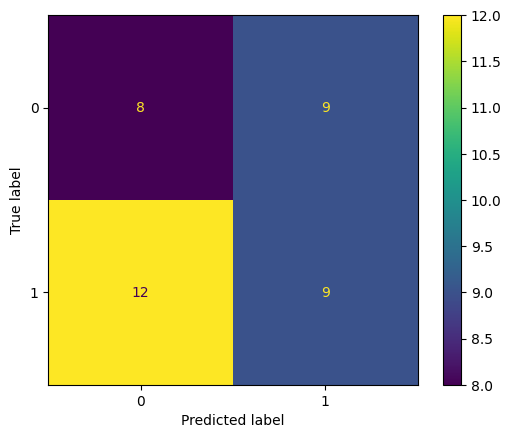

In [11]:
from sklearn.tree import ExtraTreeClassifier

# Initialize ExtraTreeClassifier
et_classifier = ExtraTreeClassifier(random_state=seed)

model_run(et_classifier, 'ExtraTreeClassifier', X_train, y_train, X_test, y_test)

running LabelPropagation with lazy_predict
Accuracy            0.42
Balanced Accuracy   0.43
ROC AUC             0.43
F1 Score            0.42
Time Taken          0.02
Name: LabelPropagation, dtype: float64


running LabelPropagation individually
              precision    recall  f1-score   support

           0       0.28      0.29      0.29        17
           1       0.40      0.38      0.39        21

    accuracy                           0.34        38
   macro avg       0.34      0.34      0.34        38
weighted avg       0.35      0.34      0.34        38

LabelPropagation ROC AUC: 0.34
LabelPropagation Time Taken: 0.01 seconds


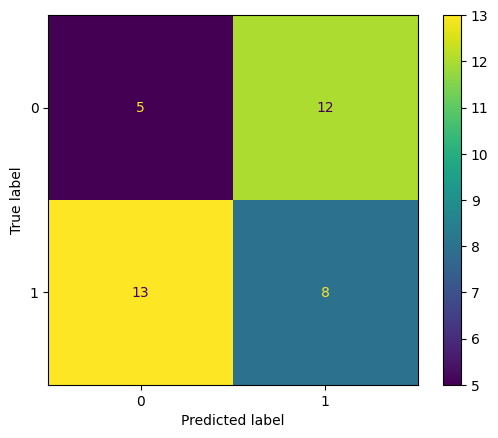

In [12]:
from sklearn.semi_supervised import LabelPropagation

label_propagation = LabelPropagation() # no seed used because LabelPropagation is deterministic
model_run(label_propagation, 'LabelPropagation', X_train, y_train, X_test, y_test)

running QuadraticDiscriminantAnalysis with lazy_predict
Accuracy            0.47
Balanced Accuracy   0.46
ROC AUC             0.46
F1 Score            0.47
Time Taken          0.03
Name: QuadraticDiscriminantAnalysis, dtype: float64


running QuadraticDiscriminantAnalysis individually
              precision    recall  f1-score   support

           0       0.40      0.35      0.38        17
           1       0.52      0.57      0.55        21

    accuracy                           0.47        38
   macro avg       0.46      0.46      0.46        38
weighted avg       0.47      0.47      0.47        38

QuadraticDiscriminantAnalysis ROC AUC: 0.46
QuadraticDiscriminantAnalysis Time Taken: 0.01 seconds


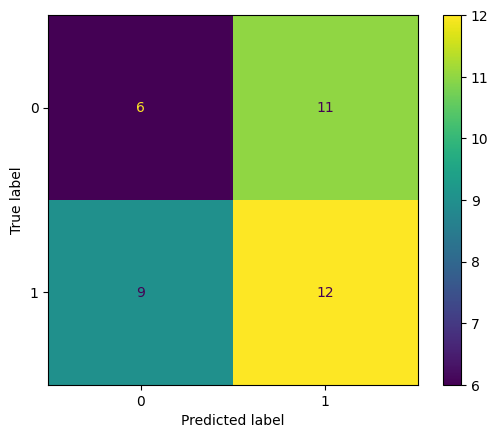

In [13]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis


quadratic_discriminant_analysis = QuadraticDiscriminantAnalysis() # no seed
model_run(quadratic_discriminant_analysis, 'QuadraticDiscriminantAnalysis', X_train, y_train, X_test, y_test)

[LightGBM] [Info] Number of positive: 48, number of negative: 40
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000036 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31
[LightGBM] [Info] Number of data points in the train set: 88, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.545455 -> initscore=0.182322
[LightGBM] [Info] Start training from score 0.182322
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

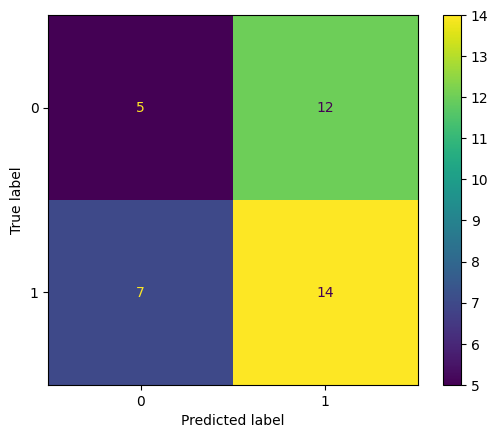

In [14]:
from lightgbm import LGBMClassifier

lgbm_classifier = LGBMClassifier(random_state=seed)
model_run(lgbm_classifier, 'LGBMClassifier', X_train, y_train, X_test, y_test)

running BernoulliNB with lazy_predict
Accuracy            0.63
Balanced Accuracy   0.63
ROC AUC             0.63
F1 Score            0.63
Time Taken          0.02
Name: BernoulliNB, dtype: float64


running BernoulliNB individually
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.55      1.00      0.71        21

    accuracy                           0.55        38
   macro avg       0.28      0.50      0.36        38
weighted avg       0.31      0.55      0.39        38

BernoulliNB ROC AUC: 0.50
BernoulliNB Time Taken: 0.00 seconds


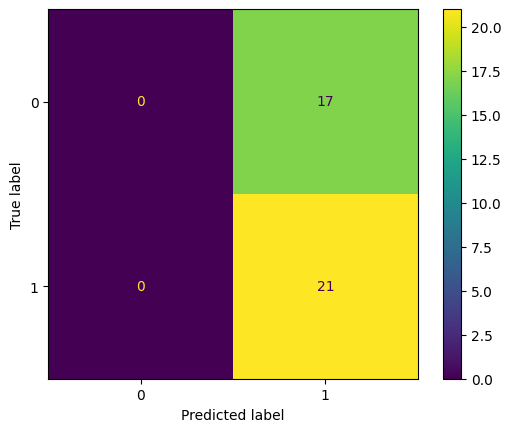

In [15]:
from sklearn.naive_bayes import BernoulliNB

bnb_classifier = BernoulliNB()
model_run(bnb_classifier, 'BernoulliNB', X_train, y_train, X_test, y_test)

bagging (bootstrapping and aggregating): have bags of random samples with replacement

boosting: the bag at the next iteration refers to the results from the previous bag

gradient boosted tree: boosting the decision trees

# Feature Selection

In [ ]:
X_feature_selected = df.iloc[:, [2, 3, 4, 5, 6]]

X_train_feature_selected, X_test_feature_selected, y_train_feature_selected, y_test_feature_selected = train_test_split(X_feature_selected, Y, test_size=0.3, random_state=seed)

In [ ]:
lazy_models_feature_selected, predictions_feature_selected = clf.fit(X_train_feature_selected, X_test_feature_selected, y_train_feature_selected, y_test)

'tuple' object has no attribute '__name__'
Invalid Classifier(s)


  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 54, number of negative: 34
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000043 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 27
[LightGBM] [Info] Number of data points in the train set: 88, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.613636 -> initscore=0.462624
[LightGBM] [Info] Start training from score 0.462624
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [ ]:
lazy_models_feature_selected

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
SGDClassifier,0.71,0.67,0.67,0.70,0.02
NearestCentroid,0.66,0.66,0.66,0.66,0.02
PassiveAggressiveClassifier,0.63,0.65,0.65,0.63,0.02
GaussianNB,0.58,0.62,0.62,0.57,0.11
BernoulliNB,0.55,0.61,0.61,0.53,0.04
LinearSVC,0.47,0.55,0.55,0.40,0.04
LogisticRegression,0.47,0.55,0.55,0.40,0.06
LinearDiscriminantAnalysis,0.47,0.55,0.55,0.40,0.02
RidgeClassifierCV,0.47,0.55,0.55,0.40,0.03


The EDA could give an assumption, but removing a feature completely could be risky.

In [16]:
from sklearn.feature_selection import RFE #recursive feature elimination

def model_run_RFE(estimator, model_instance, model_name, n_features_to_select):
  selector = RFE(estimator, n_features_to_select=n_features_to_select, step=1)
  selector = selector.fit(X_train, y_train)

  print("selected features")
  print(X.columns[selector.support_])
  print("ranking of features")
  print(selector.ranking_)
  print("\n")

  X_fs = X[X.columns[selector.support_]]
  X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(X_fs, Y, test_size=0.3, random_state=seed)

  model_run(model_instance, model_name, X_train_fs, y_train_fs, X_test_fs, y_test_fs)

selected features
Index(['X1', 'X2', 'X3', 'X5'], dtype='object')
ranking of features
[1 1 1 3 1 2]


running ExtraTreeClassifier with lazy_predict
Accuracy            0.45
Balanced Accuracy   0.45
ROC AUC             0.45
F1 Score            0.45
Time Taken          0.06
Name: ExtraTreeClassifier, dtype: float64


running ExtraTreeClassifier individually
              precision    recall  f1-score   support

           0       0.48      0.59      0.53        17
           1       0.59      0.48      0.53        21

    accuracy                           0.53        38
   macro avg       0.53      0.53      0.53        38
weighted avg       0.54      0.53      0.53        38

ExtraTreeClassifier ROC AUC: 0.53
ExtraTreeClassifier Time Taken: 0.00 seconds


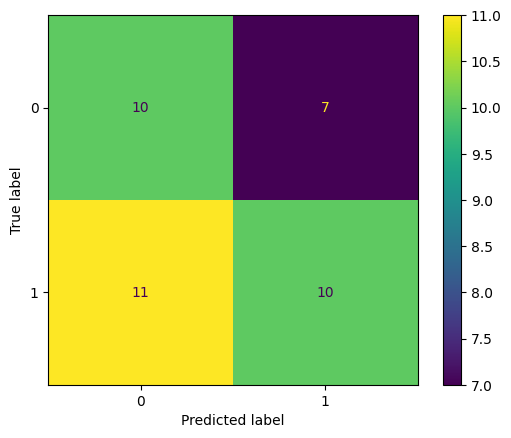

In [ ]:
model_run_RFE(et_classifier, et_classifier, 'ExtraTreeClassifier', n_features_to_select=4)


--- Running LabelPropagation with SelectKBest (selecting 4 features) ---
Selected features: ['X1', 'X3', 'X5', 'X6']

Running LabelPropagation individually (after SelectKBest)
              precision    recall  f1-score   support

           0       0.50      0.41      0.45        17
           1       0.58      0.67      0.62        21

    accuracy                           0.55        38
   macro avg       0.54      0.54      0.54        38
weighted avg       0.55      0.55      0.55        38

LabelPropagation ROC AUC: 0.54
LabelPropagation Time Taken: 0.00 seconds


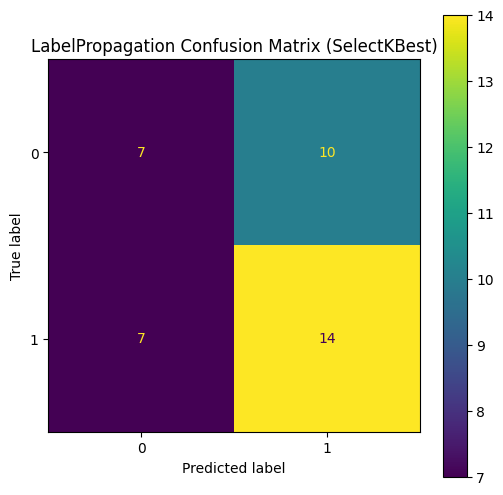

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.semi_supervised import LabelPropagation
import time
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt

def run_model_with_selectkbest(model_instance, model_name, n_features_to_select):
    print(f"\n--- Running {model_name} with SelectKBest (selecting {n_features_to_select} features) ---")

    # Feature selection using SelectKBest
    selector = SelectKBest(f_classif, k=n_features_to_select)
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)

    # Get selected feature names
    selected_features_indices = selector.get_support(indices=True)
    selected_feature_names = X.columns[selected_features_indices].tolist()
    print(f"Selected features: {selected_feature_names}")

    # Train and evaluate the model on selected features
    start_time = time.time()
    model_instance.fit(X_train_selected, y_train)
    y_pred = model_instance.predict(X_test_selected)
    end_time = time.time()
    time_taken = end_time - start_time

    roc_auc = roc_auc_score(y_test, y_pred)

    print(f"\nRunning {model_name} individually (after SelectKBest)")
    print(classification_report(y_test, y_pred))
    print(f"{model_name} ROC AUC: {roc_auc:.2f}")
    print(f"{model_name} Time Taken: {time_taken:.2f} seconds")

    fig, ax = plt.subplots(figsize=(6, 6))
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(ax=ax)
    ax.set_title(f'{model_name} Confusion Matrix (SelectKBest)')
    plt.show()

# Instantiate LabelPropagation
label_propagation_skb = LabelPropagation()

# Run the function for LabelPropagation with SelectKBest
run_model_with_selectkbest(label_propagation_skb, 'LabelPropagation', n_features_to_select=4)


--- Running QuadraticDiscriminantAnalysis with SelectKBest (selecting 4 features) ---
Selected features: ['X1', 'X3', 'X5', 'X6']

Running QuadraticDiscriminantAnalysis individually (after SelectKBest)
              precision    recall  f1-score   support

           0       0.55      0.65      0.59        17
           1       0.67      0.57      0.62        21

    accuracy                           0.61        38
   macro avg       0.61      0.61      0.60        38
weighted avg       0.61      0.61      0.61        38

QuadraticDiscriminantAnalysis ROC AUC: 0.61
QuadraticDiscriminantAnalysis Time Taken: 0.00 seconds


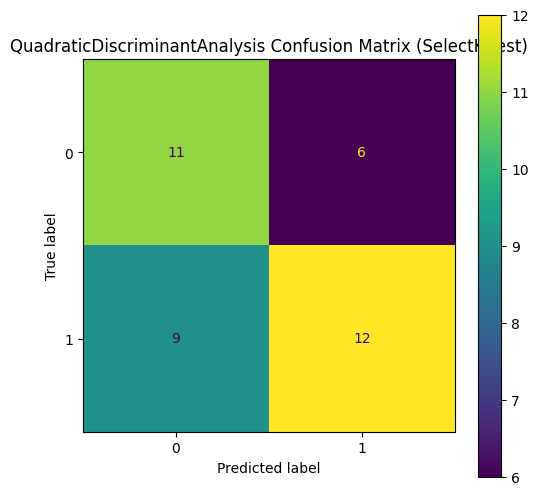

In [ ]:
run_model_with_selectkbest(quadratic_discriminant_analysis, 'QuadraticDiscriminantAnalysis', n_features_to_select=4)

[LightGBM] [Info] Number of positive: 48, number of negative: 40
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000046 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31
[LightGBM] [Info] Number of data points in the train set: 88, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.545455 -> initscore=0.182322
[LightGBM] [Info] Start training from score 0.182322
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

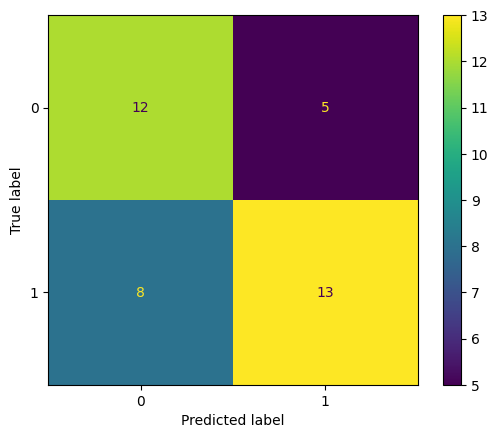

In [ ]:
model_run_RFE(lgbm_classifier, lgbm_classifier, 'LGBMClassifier', n_features_to_select=4)


--- Running BernoulliNB with SelectKBest (selecting 4 features) ---
Selected features: ['X1', 'X3', 'X5', 'X6']

Running BernoulliNB individually (after SelectKBest)
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.55      1.00      0.71        21

    accuracy                           0.55        38
   macro avg       0.28      0.50      0.36        38
weighted avg       0.31      0.55      0.39        38

BernoulliNB ROC AUC: 0.50
BernoulliNB Time Taken: 0.01 seconds


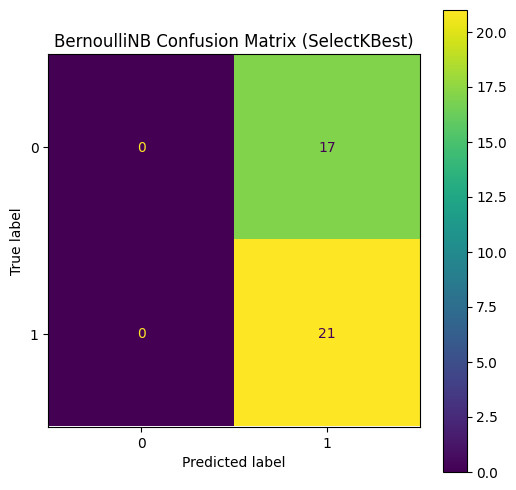

In [ ]:
run_model_with_selectkbest(bnb_classifier, 'BernoulliNB', n_features_to_select=4)

# Cross Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold
import pandas as pd
from lazypredict.Supervised import LazyClassifier

n_splits = 5 # Number of folds for cross-validation
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

cv_results = {} # To store results for each model across all folds

print(f"Running LazyClassifier with {n_splits}-fold Stratified Cross-Validation on selected features...")

for fold, (train_index, test_index) in enumerate(skf.split(X_feature_selected, Y)):
    print(f"\n--- Fold {fold+1}/{n_splits} ---")
    X_train_fold, X_test_fold = X_feature_selected.iloc[train_index], X_feature_selected.iloc[test_index]
    y_train_fold, y_test_fold = Y.iloc[train_index], Y.iloc[test_index]

    clf_cv = LazyClassifier(predictions=False, verbose=0, ignore_warnings=True)
    models_fold, _ = clf_cv.fit(X_train_fold, X_test_fold, y_train_fold, y_test_fold)

    for model_name, metrics in models_fold.iterrows():
        if model_name not in cv_results:
            cv_results[model_name] = {'Accuracy': [], 'Balanced Accuracy': [], 'ROC AUC': [], 'F1 Score': [], 'Time Taken': []}
        cv_results[model_name]['Accuracy'].append(metrics['Accuracy'])
        cv_results[model_name]['Balanced Accuracy'].append(metrics['Balanced Accuracy'])
        cv_results[model_name]['ROC AUC'].append(metrics['ROC AUC'])
        cv_results[model_name]['F1 Score'].append(metrics['F1 Score'])
        cv_results[model_name]['Time Taken'].append(metrics['Time Taken'])

print("\nCross-validation complete. Calculating average metrics...")

average_cv_metrics = {}
for model_name, metrics in cv_results.items():
    average_cv_metrics[model_name] = {
        'Accuracy': pd.Series(metrics['Accuracy']).mean(),
        'Balanced Accuracy': pd.Series(metrics['Balanced Accuracy']).mean(),
        'ROC AUC': pd.Series(metrics['ROC AUC']).mean(),
        'F1 Score': pd.Series(metrics['F1 Score']).mean(),
        'Time Taken': pd.Series(metrics['Time Taken']).mean()
    }

average_cv_performance_df = pd.DataFrame.from_dict(average_cv_metrics, orient='index')

print("\nAverage LazyClassifier Performance with 5-Fold Cross-Validation (on selected features):")
print(average_cv_performance_df.sort_values(by='Balanced Accuracy', ascending=False))

Running LazyClassifier with 5-fold Stratified Cross-Validation on selected features...

--- Fold 1/5 ---


  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 55, number of negative: 45
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000032 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24
[LightGBM] [Info] Number of data points in the train set: 100, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.550000 -> initscore=0.200671
[LightGBM] [Info] Start training from score 0.200671
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 56, number of negative: 45
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000032 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25
[LightGBM] [Info] Number of data points in the train set: 101, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.554455 -> initscore=0.218689
[LightGBM] [Info] Start training from score 0.218689
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

...

[LightGBM] [Info] Number of positive: 55, number of negative: 46
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000033 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24
[LightGBM] [Info] Number of data points in the train set: 101, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.544554 -> initscore=0.178692
[LightGBM] [Info] Start training from score 0.178692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 55, number of negative: 46
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000032 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25
[LightGBM] [Info] Number of data points in the train set: 101, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.544554 -> initscore=0.178692
[LightGBM] [Info] Start training from score 0.178692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 55, number of negative: 46
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000032 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25
[LightGBM] [Info] Number of data points in the train set: 101, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.544554 -> initscore=0.178692
[LightGBM] [Info] Start training from score 0.178692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

cross validation -> the data size is already limited

right evaluation metric

more import to predict unhappy customers correctly

happy: positive (1)

unhappy: negative (0)

when true label is negative but prediction is positive -> false positive

goal: minimize false positive -> maximize the recall of the negative labels, maximize precision of positive labels, ROC, F1 score

**Out of the actual negative data points, how many were correctly predicted as negative?**

Out of the positive predicions, how many of them were actually positive?

Accuracy: accuracy classification score

Balanced Accuracy: balanced accuracy (imbalance in the dataset?)

ROC: area under the receiver operating characteristic curve (true positive rate vs false positive rate)

F1 score: harmonic mean of the precision and recall

precision: true positive / (true positive + false postive)

recall = true positive / (true positive + false negative)

# Ensembling

[LightGBM] [Info] Number of positive: 48, number of negative: 40
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000033 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31
[LightGBM] [Info] Number of data points in the train set: 88, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.545455 -> initscore=0.182322
[LightGBM] [Info] Start training from score 0.182322
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

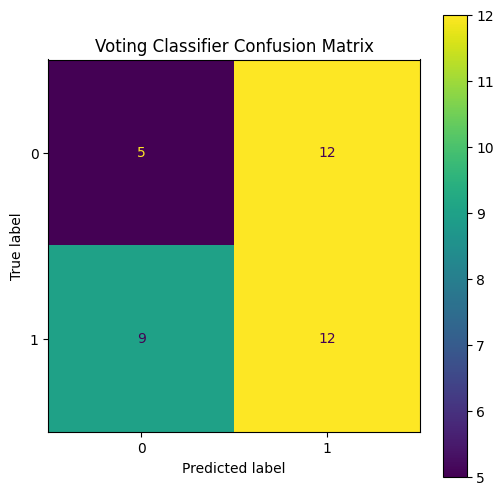

In [17]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.semi_supervised import LabelPropagation
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Instantiate some of the top-performing models from cross-validation
# Note: LabelPropagation does not take random_state, so it's initialized without it.
clf1 = LabelPropagation()
clf2 = LGBMClassifier(random_state=seed)
clf3 = RandomForestClassifier(random_state=seed)

eclf1 = VotingClassifier(estimators=[('lp', clf1), ('lgbm', clf2), ('rf', clf3)], voting='soft', weights=[1, 2, 1])
eclf1 = eclf1.fit(X_train, y_train)
y_pred_ensemble = eclf1.predict(X_test)

print("Voting Classifier (Soft Voting) Performance:")
print(classification_report(y_test, y_pred_ensemble))
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_ensemble):.2f}")

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_ensemble)).plot(ax=ax)
ax.set_title('Voting Classifier Confusion Matrix')
plt.show()

[LightGBM] [Info] Number of positive: 48, number of negative: 40
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000028 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20
[LightGBM] [Info] Number of data points in the train set: 88, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.545455 -> initscore=0.182322
[LightGBM] [Info] Start training from score 0.182322
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

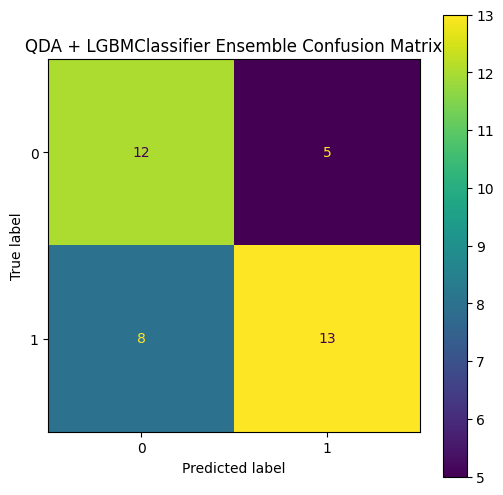

In [18]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt

# Define the columns to be used
selected_columns = ['X1', 'X3', 'X5', 'X6']

# Select the features for training and testing
X_train_selected = X_train[selected_columns]
X_test_selected = X_test[selected_columns]

# Instantiate the models
clf1 = QuadraticDiscriminantAnalysis() # No random_state for QDA
clf2 = LGBMClassifier(random_state=seed)

# Create a VotingClassifier with soft voting
# Assigning a slightly higher weight to LGBMClassifier based on its generally better performance
eclf_qda_lgbm = VotingClassifier(estimators=[('qda', clf1), ('lgbm', clf2)], voting='soft', weights=[1, 2])

# Train the ensemble model with selected features
eclf_qda_lgbm = eclf_qda_lgbm.fit(X_train_selected, y_train)
y_pred_ensemble_qda_lgbm = eclf_qda_lgbm.predict(X_test_selected)

print("Voting Classifier (QuadraticDiscriminantAnalysis + LGBMClassifier) Performance:")
print(classification_report(y_test, y_pred_ensemble_qda_lgbm))
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_ensemble_qda_lgbm):.2f}")

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_ensemble_qda_lgbm)).plot(ax=ax)
ax.set_title('QDA + LGBMClassifier Ensemble Confusion Matrix')
plt.show()


--- Running Voting Classifier (QDA + LGBM + ExtraTreeClassifier + BernoulliNB) with specific features ---
[LightGBM] [Info] Number of positive: 48, number of negative: 40
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000022 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20
[LightGBM] [Info] Number of data points in the train set: 88, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.545455 -> initscore=0.182322
[LightGBM] [Info] Start training from score 0.182322
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

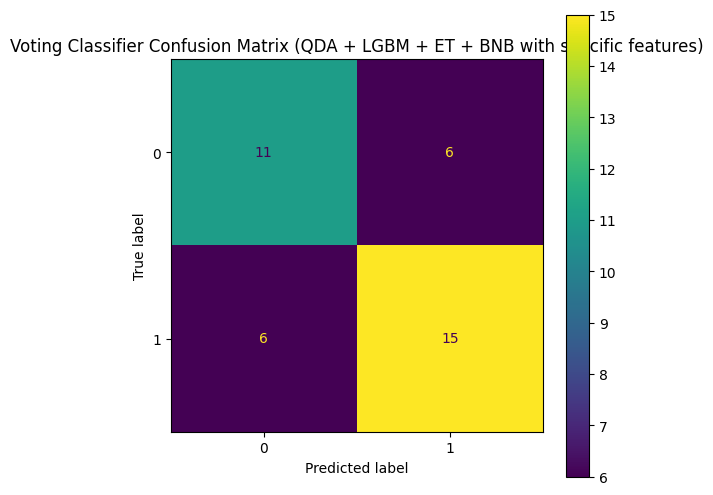

In [19]:
from sklearn.ensemble import VotingClassifier
from sklearn.tree import ExtraTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import BernoulliNB # Import BernoulliNB
import matplotlib.pyplot as plt

print("\n--- Running Voting Classifier (QDA + LGBM + ExtraTreeClassifier + BernoulliNB) with specific features ---")

# Define the columns to be used as requested
selected_columns = ['X1', 'X3', 'X5', 'X6']

# Select the features for training and testing
X_train_selected = X_train[selected_columns]
X_test_selected = X_test[selected_columns]

# Instantiate the models
clf1_qda = QuadraticDiscriminantAnalysis() # No random_state for QDA
clf2_lgbm = LGBMClassifier(random_state=seed)
clf3_et = ExtraTreeClassifier(random_state=seed)
clf4_bnb = BernoulliNB() # Instantiate BernoulliNB

# Create a VotingClassifier with soft voting
# You can adjust weights based on observed performance or intuition
eclf_qda_lgbm_et_bnb = VotingClassifier(
    estimators=[('qda', clf1_qda), ('lgbm', clf2_lgbm), ('et', clf3_et), ('bnb', clf4_bnb)],
    voting='soft',
    weights=[1, 2, 1, 1] # Adjusted weights for four classifiers
)

# Train the ensemble model with selected features
eclf_qda_lgbm_et_bnb.fit(X_train_selected, y_train)
y_pred_ensemble_qda_lgbm_et_bnb = eclf_qda_lgbm_et_bnb.predict(X_test_selected)

print("\nVoting Classifier (QDA + LGBM + ExtraTreeClassifier + BernoulliNB) Performance:")
print(classification_report(y_test, y_pred_ensemble_qda_lgbm_et_bnb))
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_ensemble_qda_lgbm_et_bnb):.2f}")

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_ensemble_qda_lgbm_et_bnb)).plot(ax=ax)
ax.set_title('Voting Classifier Confusion Matrix (QDA + LGBM + ET + BNB with specific features)')
plt.show()


--- Running Voting Classifier (QDA + LGBM + ExtraTreeClassifier) ---
[LightGBM] [Info] Number of positive: 48, number of negative: 40
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000023 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31
[LightGBM] [Info] Number of data points in the train set: 88, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.545455 -> initscore=0.182322
[LightGBM] [Info] Start training from score 0.182322
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


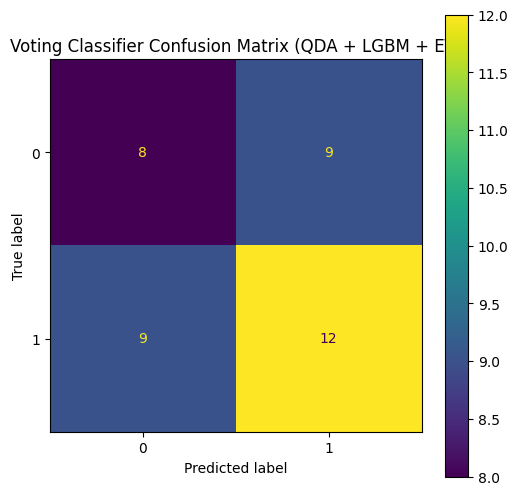

In [21]:
from sklearn.ensemble import VotingClassifier
from sklearn.tree import ExtraTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt

print("\n--- Running Voting Classifier (QDA + LGBM + ExtraTreeClassifier) ---")

# Define the columns to be used
selected_columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=seed)

# Select the features for training and testing
X_train_selected = X_train[selected_columns]
X_test_selected = X_test[selected_columns]

# Instantiate the models
clf1_qda = QuadraticDiscriminantAnalysis() # No random_state for QDA
clf2_lgbm = LGBMClassifier(random_state=seed)
clf3_et = ExtraTreeClassifier(random_state=seed)

# Create a VotingClassifier with soft voting
# You can adjust weights based on observed performance or intuition
eclf_qda_lgbm_et = VotingClassifier(
    estimators=[('qda', clf1_qda), ('lgbm', clf2_lgbm), ('et', clf3_et)],
    voting='soft',
    weights=[1, 2, 1] # Giving LGBM a higher weight as it performed well
)

# Train the ensemble model with selected features
eclf_qda_lgbm_et.fit(X_train_selected, y_train)
y_pred_ensemble_qda_lgbm_et = eclf_qda_lgbm_et.predict(X_test_selected)

print("\nVoting Classifier (QDA + LGBM + ExtraTreeClassifier) Performance:")
print(classification_report(y_test, y_pred_ensemble_qda_lgbm_et))
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_ensemble_qda_lgbm_et):.2f}")

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_ensemble_qda_lgbm_et)).plot(ax=ax)
ax.set_title('Voting Classifier Confusion Matrix (QDA + LGBM + ET)')
plt.show()


--- Running Custom Weighted Averaging Ensemble ---
[LightGBM] [Info] Number of positive: 48, number of negative: 40
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000042 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26
[LightGBM] [Info] Number of data points in the train set: 88, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.545455 -> initscore=0.182322
[LightGBM] [Info] Start training from score 0.182322
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warnin

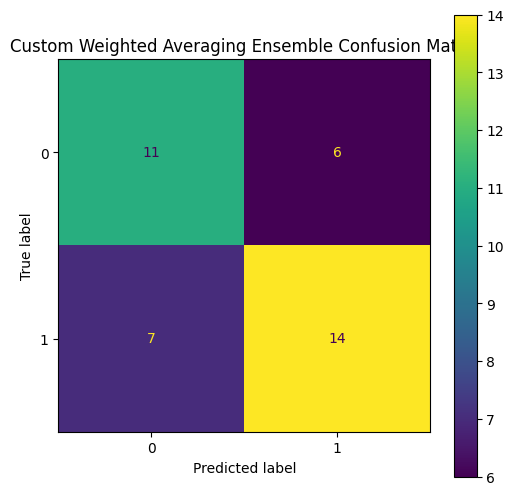

In [ ]:
import numpy as np
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("\n--- Running Custom Weighted Averaging Ensemble ---")

# Define the columns to be used
selected_columns = ['X1', 'X2', 'X3', 'X5', 'X6']

# Select the features for training and testing
X_train_selected = X_train[selected_columns]
X_test_selected = X_test[selected_columns]

# Instantiate and train the individual models
clf_qda = QuadraticDiscriminantAnalysis()
clf_qda.fit(X_train_selected, y_train)

clf_lgbm = LGBMClassifier(random_state=seed)
clf_lgbm.fit(X_train_selected, y_train)

# Get predicted probabilities for the positive class
prob_qda = clf_qda.predict_proba(X_test_selected)[:, 1]
prob_lgbm = clf_lgbm.predict_proba(X_test_selected)[:, 1]

# Define weights (you can adjust these based on individual model performance or intuition)
# For example, if LGBM generally performs better, give it a higher weight
weight_qda = 0.3
weight_lgbm = 0.7

# Calculate weighted average of probabilities
weighted_avg_prob = (prob_qda * weight_qda) + (prob_lgbm * weight_lgbm)

# Convert probabilities to class predictions (using a 0.5 threshold)
y_pred_custom_ensemble = (weighted_avg_prob > 0.5).astype(int)

print("\nCustom Weighted Averaging Ensemble Performance:")
print(classification_report(y_test, y_pred_custom_ensemble))
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_custom_ensemble):.2f}")

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_custom_ensemble)).plot(ax=ax)
ax.set_title('Custom Weighted Averaging Ensemble Confusion Matrix')
plt.show()


--- Running StackingClassifier ---
[LightGBM] [Info] Number of positive: 48, number of negative: 40
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000066 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26
[LightGBM] [Info] Number of data points in the train set: 88, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.545455 -> initscore=0.182322
[LightGBM] [Info] Start training from score 0.182322
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

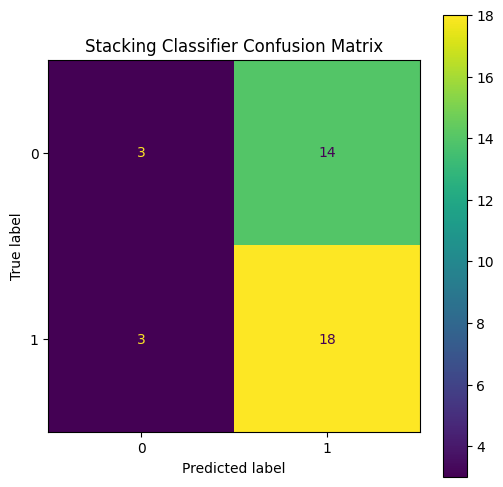

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("\n--- Running StackingClassifier ---")

# Define the columns to be used (from previous best result)
selected_columns = ['X1', 'X2', 'X3', 'X5', 'X6']

# Select the features for training and testing
X_train_selected = X_train[selected_columns]
X_test_selected = X_test[selected_columns]

# Instantiate the base models
est_qda = QuadraticDiscriminantAnalysis()
est_lgbm = LGBMClassifier(random_state=seed)

# Define the base estimators for stacking
estimators = [
    ('qda', est_qda),
    ('lgbm', est_lgbm)
]

# Instantiate the StackingClassifier with a final estimator
# Using LogisticRegression as the final estimator (meta-model)
stk_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state=seed),
    cv=5 # Use 5-fold cross-validation to generate meta-features
)

# Train the stacking ensemble model with selected features
stk_clf.fit(X_train_selected, y_train)
y_pred_stacking = stk_clf.predict(X_test_selected)

print("\nStacking Classifier Performance:")
print(classification_report(y_test, y_pred_stacking))
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_stacking):.2f}")

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_stacking)).plot(ax=ax)
ax.set_title('Stacking Classifier Confusion Matrix')
plt.show()

predict unhappy customers robustly

find what survey questions are the most significant for determining the customers' happiness

Ensembling

Voting Classifier: pros and cons with the dominant classifier

feature elimination - business perspective


--- Running Voting Classifier with SelectKBest (selecting 4 features) ---
Selected features: ['X1', 'X3', 'X5', 'X6']
[LightGBM] [Info] Number of positive: 48, number of negative: 40
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000033 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20
[LightGBM] [Info] Number of data points in the train set: 88, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.545455 -> initscore=0.182322
[LightGBM] [Info] Start training from score 0.182322
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

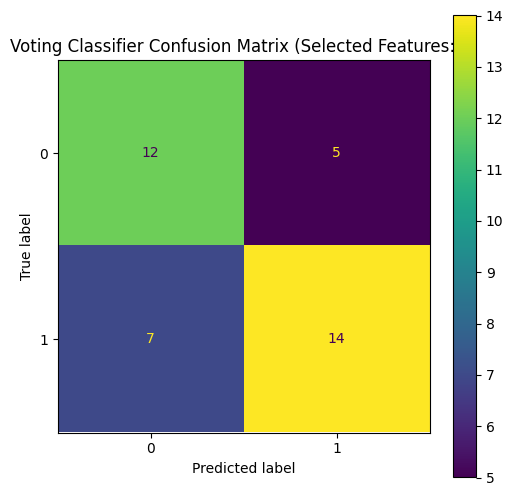

In [28]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import VotingClassifier
from sklearn.tree import ExtraTreeClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def train_and_evaluate_voting_classifier_with_feature_selection(n_features_to_select):
    print(f"\n--- Running Voting Classifier with SelectKBest (selecting {n_features_to_select} features) ---")

    # 2.b. Instantiate SelectKBest
    selector = SelectKBest(f_classif, k=n_features_to_select)

    # 2.c. Apply the SelectKBest transformer
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)

    # Get selected feature names
    selected_feature_names = X.columns[selector.get_support(indices=True)].tolist()
    print(f"Selected features: {selected_feature_names}")

    # 2.e. Instantiate QuadraticDiscriminantAnalysis
    clf1_qda = QuadraticDiscriminantAnalysis()

    # 2.f. Instantiate LGBMClassifier
    clf2_lgbm = LGBMClassifier(random_state=seed)

    # 2.g. Instantiate ExtraTreeClassifier
    clf3_et = ExtraTreeClassifier(random_state=seed)

    # 2.i. Create a VotingClassifier with soft voting
    eclf_qda_lgbm_et = VotingClassifier(
        estimators=[('qda', clf1_qda), ('lgbm', clf2_lgbm), ('et', clf3_et)],
        voting='soft',
        weights=[1, 2, 1] # Giving LGBM a higher weight as it performed well
    )

    # 2.j. Fit this VotingClassifier on X_train_selected and y_train
    eclf_qda_lgbm_et.fit(X_train_selected, y_train)

    # 2.k. Make predictions on X_test_selected
    y_pred_ensemble = eclf_qda_lgbm_et.predict(X_test_selected)

    # 2.l. Print the classification_report
    print(f"\nVoting Classifier Performance (selected features: {selected_feature_names}):")
    print(classification_report(y_test, y_pred_ensemble))

    # 2.m. Print the ROC AUC score
    print(f"ROC AUC: {roc_auc_score(y_test, y_pred_ensemble):.2f}")

    # 2.n. Display the confusion matrix
    fig, ax = plt.subplots(figsize=(6, 6))
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_ensemble)).plot(ax=ax)
    ax.set_title(f'Voting Classifier Confusion Matrix (Selected Features: {n_features_to_select})')
    plt.show()

# 3. Call the function with n_features_to_select
train_and_evaluate_voting_classifier_with_feature_selection(n_features_to_select=4)


--- Running Voting Classifier with SelectKBest (selecting 4 features) ---
Selected features: ['X1', 'X3', 'X5', 'X6']
[LightGBM] [Info] Number of positive: 48, number of negative: 40
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000036 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20
[LightGBM] [Info] Number of data points in the train set: 88, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.545455 -> initscore=0.182322
[LightGBM] [Info] Start training from score 0.182322
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

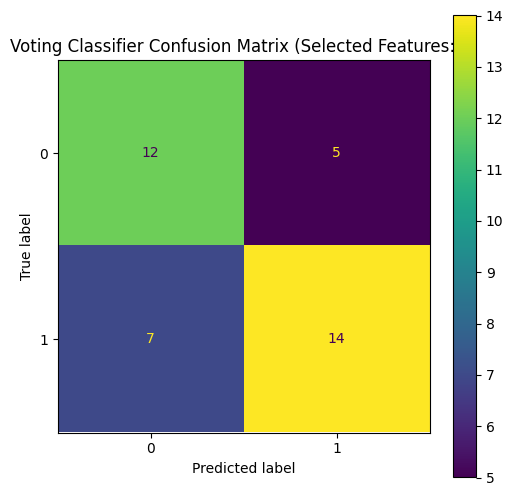

In [29]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import VotingClassifier
from sklearn.tree import ExtraTreeClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def train_and_evaluate_voting_classifier_with_feature_selection(n_features_to_select):
    print(f"\n--- Running Voting Classifier with SelectKBest (selecting {n_features_to_select} features) ---")

    # 2.b. Instantiate SelectKBest
    selector = SelectKBest(f_classif, k=n_features_to_select)

    # 2.c. Apply the SelectKBest transformer
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)

    # Get selected feature names
    selected_feature_names = X.columns[selector.get_support(indices=True)].tolist()
    print(f"Selected features: {selected_feature_names}")

    # 2.e. Instantiate QuadraticDiscriminantAnalysis
    clf1_qda = QuadraticDiscriminantAnalysis()

    # 2.f. Instantiate LGBMClassifier
    clf2_lgbm = LGBMClassifier(random_state=seed)

    # 2.g. Instantiate ExtraTreeClassifier
    clf3_et = ExtraTreeClassifier(random_state=seed)

    # 2.i. Create a VotingClassifier with soft voting
    eclf_qda_lgbm_et = VotingClassifier(
        estimators=[('qda', clf1_qda), ('lgbm', clf2_lgbm), ('et', clf3_et)],
        voting='soft',
        weights=[1, 2, 1] # Giving LGBM a higher weight as it performed well
    )

    # 2.j. Fit this VotingClassifier on X_train_selected and y_train
    eclf_qda_lgbm_et.fit(X_train_selected, y_train)

    # 2.k. Make predictions on X_test_selected
    y_pred_ensemble = eclf_qda_lgbm_et.predict(X_test_selected)

    # 2.l. Print the classification_report
    print(f"\nVoting Classifier Performance (selected features: {selected_feature_names}):")
    print(classification_report(y_test, y_pred_ensemble))

    # 2.m. Print the ROC AUC score
    print(f"ROC AUC: {roc_auc_score(y_test, y_pred_ensemble):.2f}")

    # 2.n. Display the confusion matrix
    fig, ax = plt.subplots(figsize=(6, 6))
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_ensemble)).plot(ax=ax)
    ax.set_title(f'Voting Classifier Confusion Matrix (Selected Features: {n_features_to_select})')
    plt.show()

# 3. Call the function with n_features_to_select
train_and_evaluate_voting_classifier_with_feature_selection(n_features_to_select=4)


--- Running Voting Classifier with SelectKBest (selecting 4 features) ---
Selected features: ['X1', 'X3', 'X5', 'X6']
[LightGBM] [Info] Number of positive: 48, number of negative: 40
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000027 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20
[LightGBM] [Info] Number of data points in the train set: 88, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.545455 -> initscore=0.182322
[LightGBM] [Info] Start training from score 0.182322
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

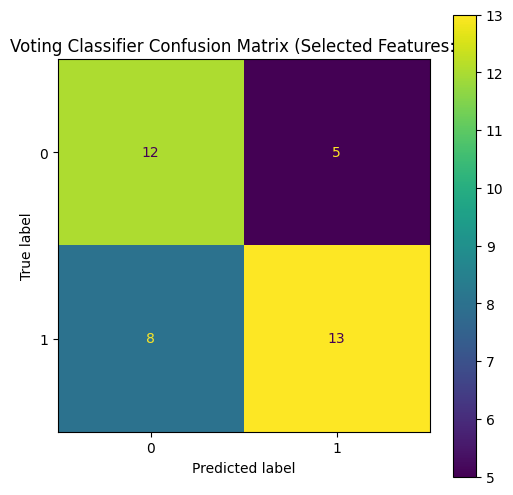

In [30]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import VotingClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def train_and_evaluate_voting_classifier_with_feature_selection(n_features_to_select):
    print(f"\n--- Running Voting Classifier with SelectKBest (selecting {n_features_to_select} features) ---")

    # Instantiate SelectKBest
    selector = SelectKBest(f_classif, k=n_features_to_select)

    # Apply the SelectKBest transformer
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)

    # Get selected feature names
    selected_feature_names = X.columns[selector.get_support(indices=True)].tolist()
    print(f"Selected features: {selected_feature_names}")

    # Instantiate QuadraticDiscriminantAnalysis
    clf1_qda = QuadraticDiscriminantAnalysis()

    # Instantiate LGBMClassifier
    clf2_lgbm = LGBMClassifier(random_state=seed)

    # Create a VotingClassifier with soft voting, using only QDA and LGBM with specified weights
    eclf_qda_lgbm = VotingClassifier(
        estimators=[('qda', clf1_qda), ('lgbm', clf2_lgbm)],
        voting='soft',
        weights=[1, 2] # Weights adjusted as per instructions
    )

    # Fit this VotingClassifier on X_train_selected and y_train
    eclf_qda_lgbm.fit(X_train_selected, y_train)

    # Make predictions on X_test_selected
    y_pred_ensemble = eclf_qda_lgbm.predict(X_test_selected)

    # Print the classification_report
    print(f"\nVoting Classifier Performance (selected features: {selected_feature_names}):")
    print(classification_report(y_test, y_pred_ensemble))

    # Print the ROC AUC score
    print(f"ROC AUC: {roc_auc_score(y_test, y_pred_ensemble):.2f}")

    # Display the confusion matrix
    fig, ax = plt.subplots(figsize=(6, 6))
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_ensemble)).plot(ax=ax)
    ax.set_title(f'Voting Classifier Confusion Matrix (Selected Features: {n_features_to_select})')
    plt.show()

# Call the function with n_features_to_select=4
train_and_evaluate_voting_classifier_with_feature_selection(n_features_to_select=4)


# Conclusion

The project aims to predict the customers' happiness based on survey data.

To establish a baseline, I utilized LazyPredict to evaluate a wide range of machine learning models. By experimenting with various train-test splits and random seed values, I found models that consistently had had top performances: ExtraTreeClassifier, LabelPropagation, QuadraticDiscriminantAnalysis, LGBMClassifier, BernoulliNB consistently.

Following the initial analysis, I conducted more in-depth analysis on the selected models using their source libraries. After analyzing the performance metrics and confusion matrices, I narrowed down the list to ExtraTreeClassifier, QuadraticDiscriminantAnalysis and LGBMClassifier. Two models were eliminated during the process:
- The LabelPropagation model had poorer performance when running it with the source code, compared to running it with LazyPredict.
- The BernoulliNB model predicted all data points to be positive, as shown by its confusion matrix, which resulted in misleading performance scores.

To further enhance model performance, I applied feature selection / recursive feature elimination and ensembling techniques. I was careful that the ensembled model was passed to the estimator to ensure that the features selected reflected the ensembling models' choices.

The final implementation used a voting classifier that combined QuadraticDiscriminantAnalysis, LGBMClassifier and ExtraTreeClassifier. Using a refined feature set of X1 (my order was delivered on time), X3 (I ordered everything I wanted to order), X5 (I am satisfied with my courier), X6 (the app makes ordering easy for me), the model achieved the accuracy of 68%. I determined this set was optimal because eliminating the features further led to poorer performance.

My analysis led to key insights into the customer behavior:
- From the business perspective, I believe feature X4 (I paid a good price for my order) has small relavance to the customers' happiness. Customers who order  online tend to prioritize convenience over cost: they are aware that online orders are pricier than purchasing in-person.
- I had an intuition that feature X2 (contents of my order was as I expected) would significantly contribute to the customers' happiness. However, the violin showed nearly identical distributions for both happy and unhappy customers. This analysis indicates that the feature doesn't have a big impact on determining the customers' happiness.

I suggest the company to focus on features X1, X3, X5, X6 and improve the related operations. For predicting customer happiness, I suggest adapting the voting classifier(QuadraticDiscriminantAnalysis, LGBMClassifier and ExtraTreeClassifier) model.